In [36]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt

In [37]:
data_covid = pd.read_csv ('Weekly_United_States_COVID-19_Cases_and_Deaths_by_State.csv') 

In [38]:
data_covid.head()

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
0,2020-01-23,AK,2020-01-16,2020-01-22,0,0,0,0,0,0
1,2020-01-30,AK,2020-01-23,2020-01-29,0,0,0,0,0,0
2,2020-02-06,AK,2020-01-30,2020-02-05,0,0,0,0,0,0
3,2020-02-13,AK,2020-02-06,2020-02-12,0,0,0,0,0,0
4,2020-02-20,AK,2020-02-13,2020-02-19,0,0,0,0,0,0


Extract data for Carlifornia 

Features Explanation: 
- data_updated: date of data release
- state: Jurisdiction 
- start_date: first day of 7-day period
- end_date: final day of 7-day period
- tot_cases: Cumulative total number of cases
- new_cases: Number of new cases (7-day sum)
- tot_deaths: Cumulative total number of deaths
- new_deaths: Number of new deaths (7-day sum)
- new_historic_cases: Number of new historic cases (7-day sum)
- new_historic_deaths: Number of new historic deaths (7-day sum)

In [39]:
covid_CA = data_covid[data_covid['state'] == 'CA']
covid_CA.head()

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
780,2020-01-23,CA,2020-01-16,2020-01-22,0,0,0,0,0,0
781,2020-01-30,CA,2020-01-23,2020-01-29,2,2,0,0,0,0
782,2020-02-06,CA,2020-01-30,2020-02-05,8,6,0,0,0,0
783,2020-02-13,CA,2020-02-06,2020-02-12,16,8,0,0,0,0
784,2020-02-20,CA,2020-02-13,2020-02-19,30,14,0,0,0,0


In [40]:
covid_CA[covid_CA['date_updated'] == '2022-01-13']

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
883,2022-01-13,CA,2022-01-06,2022-01-12,6623538,790954,76683,630,0,0


In [41]:
covid_CA.shape

(156, 10)

In [42]:
covid_FL = data_covid[data_covid['state'] == 'FL']
covid_FL.head()

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
1560,2020-01-23,FL,2020-01-16,2020-01-22,0,0,0,0,0,0
1561,2020-01-30,FL,2020-01-23,2020-01-29,0,0,0,0,0,0
1562,2020-02-06,FL,2020-01-30,2020-02-05,0,0,0,0,0,0
1563,2020-02-13,FL,2020-02-06,2020-02-12,0,0,0,0,0,0
1564,2020-02-20,FL,2020-02-13,2020-02-19,0,0,0,0,0,0


In [43]:
covid_FL.shape

(156, 10)

In [44]:
covid_FL.columns

Index(['date_updated', 'state', 'start_date', 'end_date', 'tot_cases',
       'new_cases', 'tot_deaths', 'new_deaths', 'new_historic_cases',
       'new_historic_deaths'],
      dtype='object')

In [46]:
#check whether there are missing values for all the columns 
for i in covid_CA.columns:
    result = covid_FL[i].isna().sum()
result

0

There are no missing values for all the columns in the sub-dataframe we extracted. 

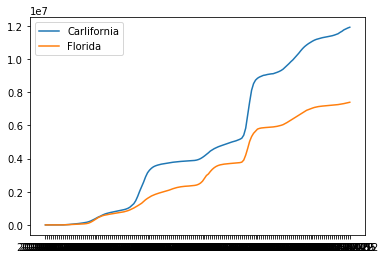

In [47]:
x = covid_CA['date_updated']

y1 = covid_CA['tot_cases']
y2 = covid_FL['tot_cases']

plt.plot(x, y1, label='Carlifornia')
plt.plot(x, y2, label='Florida')


plt.legend()

From the rough line line we can see that there are 3 time stamp makes the total cases of Carlifornia increase significantly. 

In [12]:
# find the datestamp for Carlifornia that the total cases changed the largest 

In [33]:
def find_date(df, n):
    diff_list = []
    for i in range(0, len(df['tot_cases'])-1):
        difference = (df['tot_cases'].iloc[i+1] - df['tot_cases'].iloc[i])
        diff_list.append((difference,df['date_updated'].iloc[i+1]))
        result = sorted(diff_list, reverse = True)
    return result[:n]

In [34]:
find_date(covid_CA, 3)

[(790954, '2022-01-13'), (788494, '2022-01-20'), (708364, '2022-01-27')]

In [35]:
find_date(covid_FL, 3)

[(429311, '2022-01-20'), (396562, '2022-01-13'), (302179, '2022-01-06')]

From the result we can see that 2022 January is the period that the total cases increased most significantly. when we analyze the truck and price related data, we can take a look at this period specifically. 